# Notebook 05 — Variables exógenas y SARIMAX

Este notebook tiene dos partes:

**Parte 1 — Variables exógenas solares:** se descargan datos meteorológicos
horarios de PVGIS (ERA5, API v5.3) para España (Madrid, 40.4°N, -3.7°E)
para el periodo 2005-2023. Se calcula el perfil climatológico medio hora
a hora y se construye el fichero de exógenas a resolución horaria (1h)
para el periodo 2022-2025.

**Parte 2 — Modelo SARIMAX:** se extiende el SARIMA incorporando las
variables exógenas meteorológicas como regresores externos. El uso de
perfiles climatológicos permite disponer de valores de las exógenas para
cualquier fecha futura sin necesidad de predicción, evitando fuga de
información en la evaluación.

**Evaluación:** walk-forward con 45 evaluaciones distribuidas por 2024,
paso de 8 días, ventana expansiva.

In [1]:
import pandas as pd
import numpy as np
import requests
import pvlib
from pathlib import Path

LAT      = 40.4
LON      = -3.7

BASE_DIR  = Path("/srv/TFM") if Path("/srv/TFM").exists() else Path("/home/ubuntu/TFM")
DATA_DIR  = BASE_DIR / "notebooks/data_processed"
FIG_DIR   = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)
PVGIS_URL = "https://re.jrc.ec.europa.eu/api/v5_3/seriescalc"

print(f"Coordenadas: {LAT}°N, {LON}°E")
print(f"pvlib: {pvlib.__version__}")

Coordenadas: 40.4°N, -3.7°E
pvlib: 0.15.0


## 1. Descarga de datos PVGIS ERA5 (2005-2023)

Se descargan datos horarios año a año para evitar timeouts.
Son 19 años × 8760 horas = ~166.000 observaciones horarias.
Se usa PVGIS-ERA5, base de datos de reanálisis atmosférico con
cobertura global y resolución horaria nativa.

In [2]:
def descargar_pvgis(lat, lon, year):
    params = {
        "lat": lat,
        "lon": lon,
        "startyear": year,
        "endyear": year,
        "outputformat": "json",
        "raddatabase": "PVGIS-ERA5",
        "components": 0,
        "pvcalculation": 0,
        "usehorizon": 1,
    }
    print(f"Descargando {year}...")
    r = requests.get(PVGIS_URL, params=params, timeout=120)
    r.raise_for_status()
    
    hourly = r.json()["outputs"]["hourly"]
    df = pd.DataFrame(hourly)
    df["time"] = pd.to_datetime(df["time"], format="%Y%m%d:%H%M", utc=True)
    df = df.set_index("time")
    df = df.rename(columns={
        "G(i)":  "ghi",
        "H_sun": "solar_elevation"
    })
    df = df[["ghi", "solar_elevation"]].astype(float)
    print(f"  {year}: {len(df)} filas OK")
    return df

# Descargar 2005-2023
dfs = []
for year in range(2005, 2024):
    df_year = descargar_pvgis(LAT, LON, year)
    dfs.append(df_year)

df_pvgis = pd.concat(dfs).sort_index()
print(f"\nTotal descargado: {df_pvgis.shape}")
print(df_pvgis.head())

Descargando 2005...
  2005: 8760 filas OK
Descargando 2006...
  2006: 8760 filas OK
Descargando 2007...
  2007: 8760 filas OK
Descargando 2008...
  2008: 8784 filas OK
Descargando 2009...
  2009: 8760 filas OK
Descargando 2010...
  2010: 8760 filas OK
Descargando 2011...
  2011: 8760 filas OK
Descargando 2012...
  2012: 8784 filas OK
Descargando 2013...
  2013: 8760 filas OK
Descargando 2014...
  2014: 8760 filas OK
Descargando 2015...
  2015: 8760 filas OK
Descargando 2016...
  2016: 8784 filas OK
Descargando 2017...
  2017: 8760 filas OK
Descargando 2018...
  2018: 8760 filas OK
Descargando 2019...
  2019: 8760 filas OK
Descargando 2020...
  2020: 8784 filas OK
Descargando 2021...
  2021: 8760 filas OK
Descargando 2022...
  2022: 8760 filas OK
Descargando 2023...
  2023: 8760 filas OK

Total descargado: (166536, 2)
                           ghi  solar_elevation
time                                           
2005-01-01 00:30:00+00:00  0.0              0.0
2005-01-01 01:30:00+00:00  

## 2. Perfil climatológico medio

Se calcula la media histórica para cada (mes, día, hora) del año
promediando los 19 años disponibles. Este perfil típico anual
se aplica a 2022-2025 sin necesidad de predicción adicional,
garantizando que las exógenas no introduzcan fuga de información.

In [3]:
# Añadir columnas de mes, día y hora para agrupar
df_pvgis["month"] = df_pvgis.index.month
df_pvgis["day"]   = df_pvgis.index.day
df_pvgis["hour"]  = df_pvgis.index.hour

# Media histórica por (mes, día, hora)
climatologia = (
    df_pvgis
    .groupby(["month", "day", "hour"])[["ghi", "solar_elevation"]]
    .mean()
    .reset_index()
)

print(f"Perfil climatológico: {climatologia.shape}")
print(climatologia.head(10))

Perfil climatológico: (8784, 5)
   month  day  hour         ghi  solar_elevation
0      1    1     0    0.000000             0.00
1      1    1     1    0.000000             0.00
2      1    1     2    0.000000             0.00
3      1    1     3    0.000000             0.00
4      1    1     4    0.000000             0.00
5      1    1     5    0.000000             0.00
6      1    1     6    0.000000             0.00
7      1    1     7    0.000000            -2.14
8      1    1     8   72.697368             7.35
9      1    1     9  179.584737            15.49


## 3. Construcción del índice horario y azimut solar

Se construye un índice horario para 2022-2025 y se asigna el
perfil climatológico. El azimut solar se calcula con pvlib —
es una variable determinista que no requiere histórico.
Con resolución horaria no es necesaria interpolación adicional.

In [4]:
idx_horario = pd.date_range(
    start="2022-01-01 00:00:00",
    end="2025-12-31 23:00:00",
    freq="1h",
    tz="UTC"
)

df_exog = pd.DataFrame(index=idx_horario)
df_exog["month"] = df_exog.index.month
df_exog["day"]   = df_exog.index.day
df_exog["hour"]  = df_exog.index.hour

df_exog = df_exog.merge(
    climatologia,
    on=["month", "day", "hour"],
    how="left"
).set_index(idx_horario)

location = pvlib.location.Location(latitude=LAT, longitude=LON, tz="UTC")
solpos = location.get_solarposition(idx_horario)
df_exog["solar_azimuth"] = solpos["azimuth"].values

print(f"Exógenas horarias: {df_exog.shape}")
print(df_exog.head(10))

Exógenas horarias: (35064, 6)
                           month  day  hour         ghi  solar_elevation  \
2022-01-01 00:00:00+00:00      1    1     0    0.000000             0.00   
2022-01-01 01:00:00+00:00      1    1     1    0.000000             0.00   
2022-01-01 02:00:00+00:00      1    1     2    0.000000             0.00   
2022-01-01 03:00:00+00:00      1    1     3    0.000000             0.00   
2022-01-01 04:00:00+00:00      1    1     4    0.000000             0.00   
2022-01-01 05:00:00+00:00      1    1     5    0.000000             0.00   
2022-01-01 06:00:00+00:00      1    1     6    0.000000             0.00   
2022-01-01 07:00:00+00:00      1    1     7    0.000000            -2.14   
2022-01-01 08:00:00+00:00      1    1     8   72.697368             7.35   
2022-01-01 09:00:00+00:00      1    1     9  179.584737            15.49   

                           solar_azimuth  
2022-01-01 00:00:00+00:00     346.253867  
2022-01-01 01:00:00+00:00      30.073441  
2022

## 4. Limpieza y guardado

Se aplican correcciones físicas (GHI ≥ 0) y se guarda el parquet
de exógenas a resolución horaria para uso en los notebooks siguientes.

In [5]:
df_exog["ghi"]             = df_exog["ghi"].clip(lower=0)
df_exog["solar_elevation"] = df_exog["solar_elevation"].fillna(0)
df_exog["solar_azimuth"]   = df_exog["solar_azimuth"].ffill()

print(f"Exógenas: {df_exog.shape}")
print(f"NaN por columna: {df_exog.isna().sum().to_dict()}")
df_exog.to_parquet(DATA_DIR / "exogenas_1h.parquet")
print("Guardado OK -> exogenas_1h.parquet")

Exógenas: (35064, 6)
NaN por columna: {'month': 0, 'day': 0, 'hour': 0, 'ghi': 0, 'solar_elevation': 0, 'solar_azimuth': 0}
Guardado OK -> exogenas_1h.parquet


## 5. Verificación de alineación con la serie objetivo

Se verifica que el índice de las exógenas coincide exactamente
con el índice de la serie de huella de carbono a resolución horaria.

In [6]:
y_train = pd.read_parquet(DATA_DIR / "train_2022_2023.parquet")["y"]
y_val   = pd.read_parquet(DATA_DIR / "val_2024.parquet")["y"]
y_test  = pd.read_parquet(DATA_DIR / "test_2025.parquet")["y"]

y_full  = pd.concat([y_train, y_val, y_test]).sort_index()
y_full.index = pd.to_datetime(y_full.index, utc=True)

exogenas = pd.read_parquet(DATA_DIR / "exogenas_1h.parquet")

print(f"Serie huella:  {y_full.index.min()} -> {y_full.index.max()} ({len(y_full)} obs)")
print(f"Exógenas:      {exogenas.index.min()} -> {exogenas.index.max()} ({len(exogenas)} obs)")
print(f"Columnas: {exogenas.columns.tolist()}")
print(f"NaN: {exogenas.isna().sum().to_dict()}")

Serie huella:  2022-01-01 00:00:00+00:00 -> 2025-12-31 23:00:00+00:00 (35064 obs)
Exógenas:      2022-01-01 00:00:00+00:00 -> 2025-12-31 23:00:00+00:00 (35064 obs)
Columnas: ['month', 'day', 'hour', 'ghi', 'solar_elevation', 'solar_azimuth']
NaN: {'month': 0, 'day': 0, 'hour': 0, 'ghi': 0, 'solar_elevation': 0, 'solar_azimuth': 0}


## 6. Visualización del perfil climatológico

Se visualiza una semana de verano y una de invierno para verificar
que los perfiles de irradiancia y elevación solar son coherentes
con la posición geográfica de Madrid y la época del año.

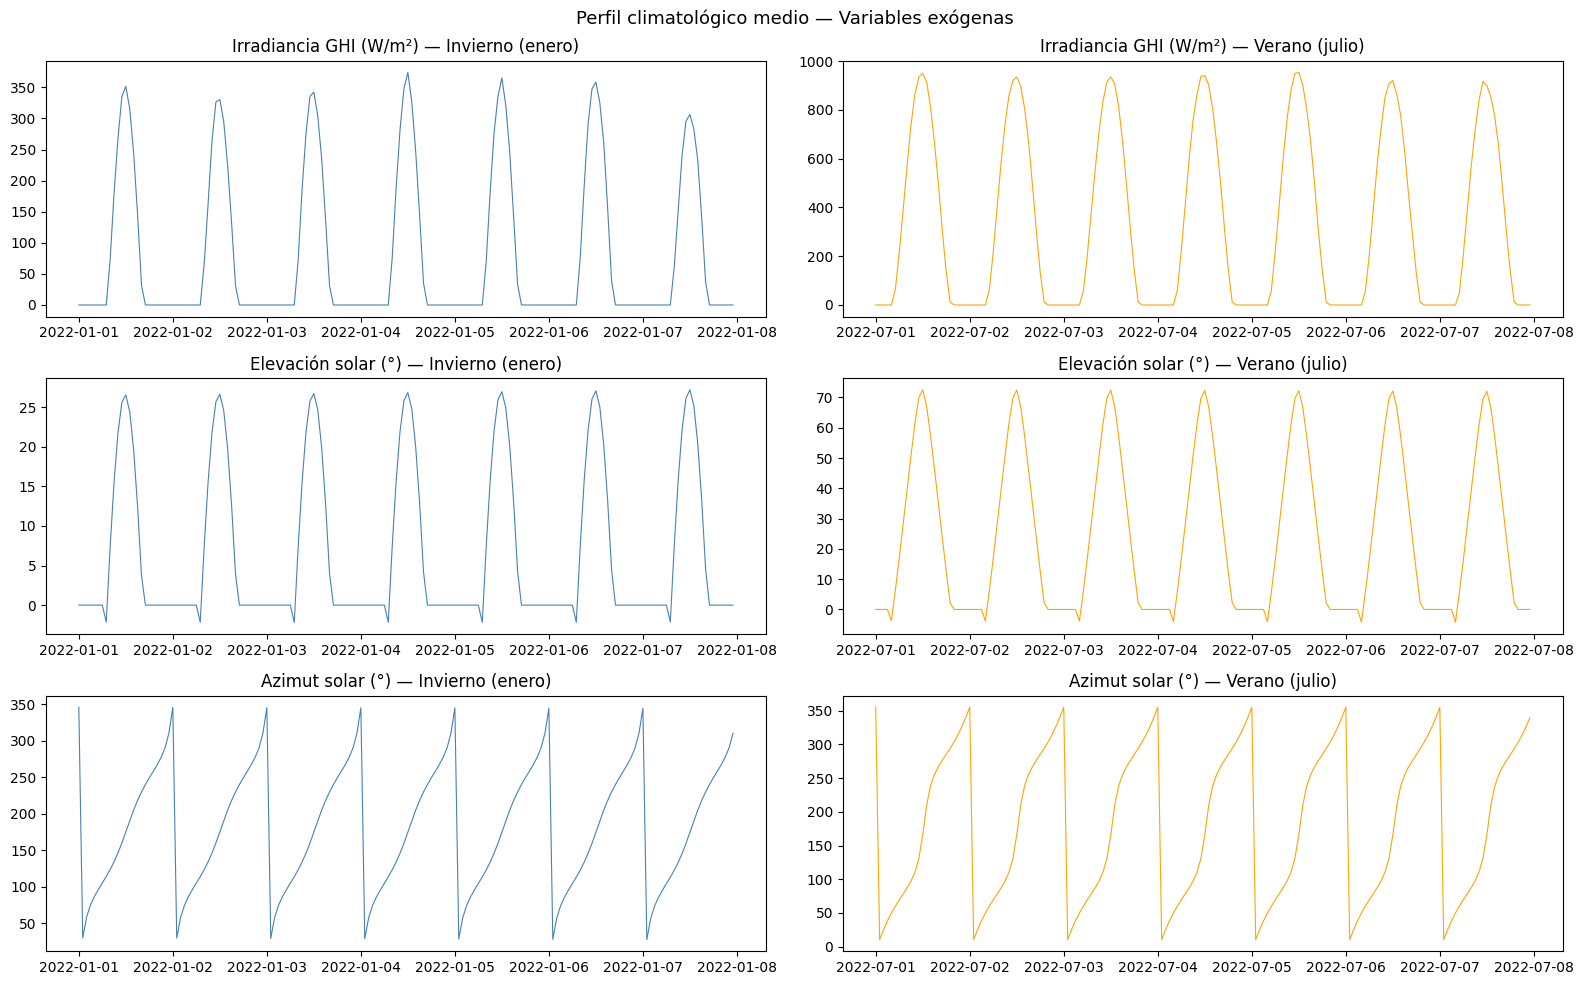

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(16, 10))
fig.suptitle("Perfil climatológico medio — Variables exógenas", fontsize=13)

verano   = df_exog.loc["2022-07-01":"2022-07-07"]
invierno = df_exog.loc["2022-01-01":"2022-01-07"]

cols   = ["ghi", "solar_elevation", "solar_azimuth"]
labels = ["Irradiancia GHI (W/m²)", "Elevación solar (°)", "Azimut solar (°)"]

for i, (col, label) in enumerate(zip(cols, labels)):
    axes[i][0].plot(invierno.index, invierno[col], color="steelblue", linewidth=0.8)
    axes[i][0].set_title(f"{label} — Invierno (enero)")
    axes[i][1].plot(verano.index, verano[col], color="orange", linewidth=0.8)
    axes[i][1].set_title(f"{label} — Verano (julio)")

plt.tight_layout()
plt.savefig(FIG_DIR / "exogenas_perfil.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Resumen — variables exógenas

Las variables exógenas están preparadas y alineadas con la serie
de huella de carbono a resolución horaria (1h).
Guardadas en `data_processed/exogenas_1h.parquet`.

| Variable | Descripción | Unidad |
|---|---|---|
| ghi | Irradiancia global horizontal (perfil climatológico medio 2005-2023) | W/m² |
| solar_elevation | Elevación del sol sobre el horizonte | grados |
| solar_azimuth | Posición horizontal del sol | grados |

# Parte 2 — Modelo SARIMAX

Se extiende el SARIMA incorporando las variables exógenas meteorológicas
como regresores externos. Con resolución horaria y s=24 el coste
computacional es asumible con 45 evaluaciones walk-forward.

Las exógenas futuras se obtienen del perfil climatológico — no requieren
predicción al ser valores medios históricos, evitando fuga de información.

**Evaluación:** walk-forward con 45 fits, paso 8 días, ventana expansiva.

In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path
import numpy as np
import pandas as pd

BASE_DIR    = Path("/srv/TFM") if Path("/srv/TFM").exists() else Path("/home/ubuntu/TFM")
DATA_DIR    = BASE_DIR / "notebooks/data_processed"
RESULTS_DIR = BASE_DIR / "results"
FIG_DIR     = BASE_DIR / "figures"
RESULTS_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

FREQ_MIN        = 60
STEPS_PER_HOUR  = 1
SEASONAL_PERIOD = 24

HORIZONS = {
    "48h": 48,
    "72h": 72,
}

@dataclass
class WFConfig:
    step: int
    min_history: int
    max_fits: int

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"MAE": mae, "RMSE": rmse}

def bootstrap_ci(errors, n_boot=1000, ci=95):
    rng = np.random.default_rng(42)
    boot_means = np.array([
        rng.choice(errors, size=len(errors), replace=True).mean()
        for _ in range(n_boot)
    ])
    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return lower, upper

def summarize_with_ci(df, model_name):
    rows = []
    for horizon, group in df.groupby("horizon"):
        mae_vals  = group["MAE"].values
        rmse_vals = group["RMSE"].values
        mae_lo,  mae_hi  = bootstrap_ci(mae_vals)
        rmse_lo, rmse_hi = bootstrap_ci(rmse_vals)
        rows.append({
            "model":      model_name,
            "horizon":    horizon,
            "MAE_mean":   mae_vals.mean(),
            "MAE_std":    mae_vals.std(),
            "MAE_ci_lo":  mae_lo,
            "MAE_ci_hi":  mae_hi,
            "RMSE_mean":  rmse_vals.mean(),
            "RMSE_std":   rmse_vals.std(),
            "n_eval":     len(mae_vals),
        })
    return pd.DataFrame(rows)

print("SEASONAL_PERIOD:", SEASONAL_PERIOD)
print("HORIZONS:", HORIZONS)

SEASONAL_PERIOD: 24
HORIZONS: {'48h': 48, '72h': 72}


## Orden SARIMAX y función de forecasting

Se usa el mismo orden obtenido con auto_arima en el notebook 04:
SARIMA(1,1,1)x(1,0,1)[24]. Mantener el mismo orden base permite
aislar el efecto de las variables exógenas en la comparación
SARIMA vs SARIMAX — la única diferencia entre ambos modelos
son los regresores externos (GHI, elevación solar y azimut solar).
La selección final de variables exógenas se analizará en el
notebook 07 mediante el pipeline progresivo de exógenas.

In [9]:
sarimax_order          = (1, 1, 1)
sarimax_seasonal_order = (1, 0, 1, 24)

def forecast_sarimax(train_y, train_exog, future_exog, h,
                     order, seasonal_order, maxiter=50):
    model = SARIMAX(
        train_y.values,
        exog=train_exog.values,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False, maxiter=maxiter,
                    low_memory=True, cov_type="none")
    return res.forecast(steps=h, exog=future_exog.values)

print(f"Orden SARIMAX: {sarimax_order}x{sarimax_seasonal_order}")

Orden SARIMAX: (1, 1, 1)x(1, 0, 1, 24)


## Evaluación walk-forward SARIMAX

45 evaluaciones con paso de 8 días, desde el 7 de enero hasta
el 24 de diciembre de 2024. Las exógenas futuras se obtienen
del perfil climatológico — libre de fuga de información.

In [10]:
def walk_forward_splits(series, horizons, cfg):
    n     = len(series)
    max_h = max(horizons.values())
    points = list(range(cfg.min_history, n - max_h, cfg.step))
    points = points[:cfg.max_fits]
    for t0 in points:
        train_part = series.iloc[:t0]
        tests = {k: series.iloc[t0:t0 + h] for k, h in horizons.items()}
        yield train_part, tests

def evaluate_sarimax(y_train, y_val, exog, horizons, cfg,
                     order, seasonal_order, verbose=True):
    rows        = []
    preds_store = []
    y_full      = pd.concat([y_train, y_val]).sort_index()
    n_train     = len(y_train)
    splits      = list(walk_forward_splits(y_val, horizons, cfg))
    total       = len(splits)

    for i, (train_part, tests) in enumerate(splits, 1):
        cutoff_idx   = n_train + len(train_part)
        cutoff_time  = y_full.index[cutoff_idx - 1]
        if verbose:
            print(f"Fit {i}/{total} — {cutoff_time.strftime('%Y-%m-%d')} — entrenando...")

        train_window = y_full.iloc[:cutoff_idx]
        train_exog   = exog.iloc[:cutoff_idx]

        fit_preds = {"cutoff_time": cutoff_time, "train_window": train_window}

        for name, test in tests.items():
            h           = len(test)
            future_exog = exog.loc[test.index]
            pred        = forecast_sarimax(
                train_window, train_exog, future_exog, h,
                order, seasonal_order
            )
            m = compute_metrics(test.values, pred)
            rows.append({"horizon": name, "MAE": m["MAE"], "RMSE": m["RMSE"]})
            fit_preds[name] = {"pred": pred, "test": test}

        preds_store.append(fit_preds)

    return pd.DataFrame(rows), preds_store

print("evaluate_sarimax definida OK")

evaluate_sarimax definida OK


## Ejecución del walk-forward

Se carga el parquet de exógenas, se alinea con la serie y se lanza
la evaluación. El resultado se guarda en `sarimax_ci.csv` para la
comparación global del notebook 07.

In [11]:
exog = pd.read_parquet(DATA_DIR / "exogenas_1h.parquet")
exog.index = pd.to_datetime(exog.index, utc=True)
exog = exog[["ghi", "solar_elevation", "solar_azimuth"]]

y_train = pd.read_parquet(DATA_DIR / "train_2022_2023.parquet")["y"].astype(float)
y_val   = pd.read_parquet(DATA_DIR / "val_2024.parquet")["y"].astype(float)
y_train.index = pd.to_datetime(y_train.index, utc=True)
y_val.index   = pd.to_datetime(y_val.index, utc=True)

cfg_sarimax = WFConfig(
    step=8 * SEASONAL_PERIOD,
    min_history=7 * SEASONAL_PERIOD,
    max_fits=45
)

PLOT_INDICES = [2, 15, 30, 42]

splits_preview = list(walk_forward_splits(y_val, HORIZONS, cfg_sarimax))
print(f"Número de fits: {len(splits_preview)}")
for i, (train_part, _) in enumerate(splits_preview):
    cutoff = y_val.index[len(train_part) - 1]
    print(f"  Fit {i+1:2d}: {cutoff.date()} ({cutoff.day_name()})")

sarimax_val, preds_store_sarimax = evaluate_sarimax(
    y_train, y_val, exog,
    HORIZONS, cfg_sarimax,
    sarimax_order, sarimax_seasonal_order,
    verbose=True
)

print("Filas generadas:", len(sarimax_val))

sarimax_ci = summarize_with_ci(sarimax_val, f"SARIMAX{sarimax_order}x{sarimax_seasonal_order}")
sarimax_ci.to_csv(RESULTS_DIR / "sarimax_ci.csv", index=False)

print("\n=== Resultados con IC 95% ===")
for _, r in sarimax_ci.iterrows():
    print(f"{r['model']:35s} {r['horizon']:4s}  "
          f"MAE = {r['MAE_mean']:6.2f} ± {r['MAE_std']:5.2f}  "
          f"IC95% [{r['MAE_ci_lo']:6.2f}, {r['MAE_ci_hi']:6.2f}]  "
          f"(n={int(r['n_eval'])})")

Número de fits: 45
  Fit  1: 2024-01-07 (Sunday)
  Fit  2: 2024-01-15 (Monday)
  Fit  3: 2024-01-23 (Tuesday)
  Fit  4: 2024-01-31 (Wednesday)
  Fit  5: 2024-02-08 (Thursday)
  Fit  6: 2024-02-16 (Friday)
  Fit  7: 2024-02-24 (Saturday)
  Fit  8: 2024-03-03 (Sunday)
  Fit  9: 2024-03-11 (Monday)
  Fit 10: 2024-03-19 (Tuesday)
  Fit 11: 2024-03-27 (Wednesday)
  Fit 12: 2024-04-04 (Thursday)
  Fit 13: 2024-04-12 (Friday)
  Fit 14: 2024-04-20 (Saturday)
  Fit 15: 2024-04-28 (Sunday)
  Fit 16: 2024-05-06 (Monday)
  Fit 17: 2024-05-14 (Tuesday)
  Fit 18: 2024-05-22 (Wednesday)
  Fit 19: 2024-05-30 (Thursday)
  Fit 20: 2024-06-07 (Friday)
  Fit 21: 2024-06-15 (Saturday)
  Fit 22: 2024-06-23 (Sunday)
  Fit 23: 2024-07-01 (Monday)
  Fit 24: 2024-07-09 (Tuesday)
  Fit 25: 2024-07-17 (Wednesday)
  Fit 26: 2024-07-25 (Thursday)
  Fit 27: 2024-08-02 (Friday)
  Fit 28: 2024-08-10 (Saturday)
  Fit 29: 2024-08-18 (Sunday)
  Fit 30: 2024-08-26 (Monday)
  Fit 31: 2024-09-03 (Tuesday)
  Fit 32: 2024-09-

/home/ubuntu/TFM/tfm_env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ubuntu/TFM/tfm_env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fit 27/45 — 2024-08-02 — entrenando...
Fit 28/45 — 2024-08-10 — entrenando...
Fit 29/45 — 2024-08-18 — entrenando...
Fit 30/45 — 2024-08-26 — entrenando...
Fit 31/45 — 2024-09-03 — entrenando...
Fit 32/45 — 2024-09-11 — entrenando...
Fit 33/45 — 2024-09-19 — entrenando...
Fit 34/45 — 2024-09-27 — entrenando...
Fit 35/45 — 2024-10-05 — entrenando...
Fit 36/45 — 2024-10-13 — entrenando...
Fit 37/45 — 2024-10-21 — entrenando...
Fit 38/45 — 2024-10-29 — entrenando...
Fit 39/45 — 2024-11-06 — entrenando...
Fit 40/45 — 2024-11-14 — entrenando...
Fit 41/45 — 2024-11-22 — entrenando...


/home/ubuntu/TFM/tfm_env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ubuntu/TFM/tfm_env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fit 42/45 — 2024-11-30 — entrenando...
Fit 43/45 — 2024-12-08 — entrenando...


/home/ubuntu/TFM/tfm_env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ubuntu/TFM/tfm_env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fit 44/45 — 2024-12-16 — entrenando...
Fit 45/45 — 2024-12-24 — entrenando...
Filas generadas: 90

=== Resultados con IC 95% ===
SARIMAX(1, 1, 1)x(1, 0, 1, 24)      48h   MAE =  22.20 ± 15.74  IC95% [ 17.91,  27.18]  (n=45)
SARIMAX(1, 1, 1)x(1, 0, 1, 24)      72h   MAE =  26.79 ± 19.10  IC95% [ 21.52,  32.98]  (n=45)


## Visualización SARIMAX — predicciones vs real (48h)

Se muestran las predicciones a 48h del modelo SARIMAX en 4 puntos
distribuidos por 2024 para evaluar visualmente la mejora sobre
SARIMA al incorporar las variables exógenas solares.

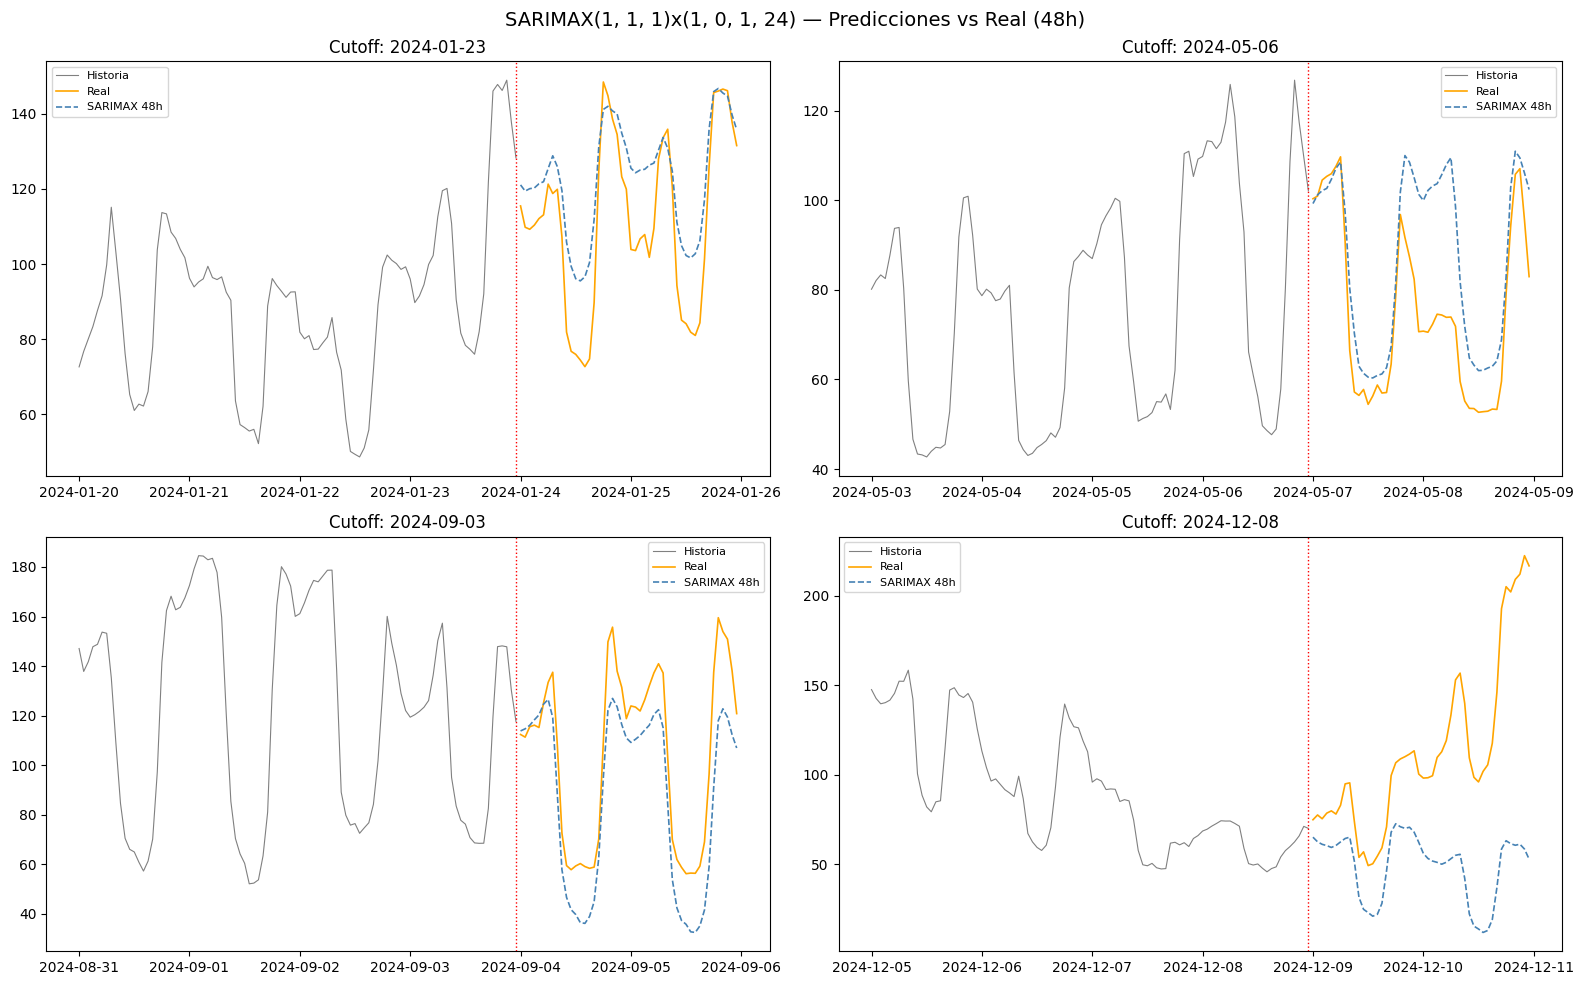

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f"SARIMAX{sarimax_order}x{sarimax_seasonal_order} — Predicciones vs Real (48h)", fontsize=14)

for idx, split_idx in enumerate(PLOT_INDICES):
    ax          = axes[idx // 2][idx % 2]
    fit         = preds_store_sarimax[split_idx]
    cutoff_time = fit["cutoff_time"]
    train_w     = fit["train_window"]
    test        = fit["48h"]["test"]
    pred        = fit["48h"]["pred"]
    history     = train_w.iloc[-4 * SEASONAL_PERIOD:]

    ax.plot(history.index, history.values,
            color="gray", label="Historia", linewidth=0.8)
    ax.plot(test.index, test.values,
            color="orange", label="Real", linewidth=1.2)
    ax.plot(test.index, pred,
            color="steelblue", linestyle="--",
            label="SARIMAX 48h", linewidth=1.2)
    ax.axvline(x=cutoff_time, color="red", linestyle=":", linewidth=1)
    ax.set_title(f"Cutoff: {cutoff_time.date()}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "sarimax_predicciones.png", dpi=150, bbox_inches="tight")
plt.show()